In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris = sns.load_dataset('iris')
# Verify load
print('Dataset shape:', iris.shape)
iris.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# 1. Feature list and types
feature_types = iris.dtypes
print('\nFeature types:')
print(feature_types)
numeric_features = iris.select_dtypes(include=['float64',
'int64']).columns.tolist()
categorical_features = iris.select_dtypes(include=['object',
'category']).columns.tolist()
print('\nNumeric features:', numeric_features)
print('Categorical features:', categorical_features)


Feature types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Numeric features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Categorical features: ['species']


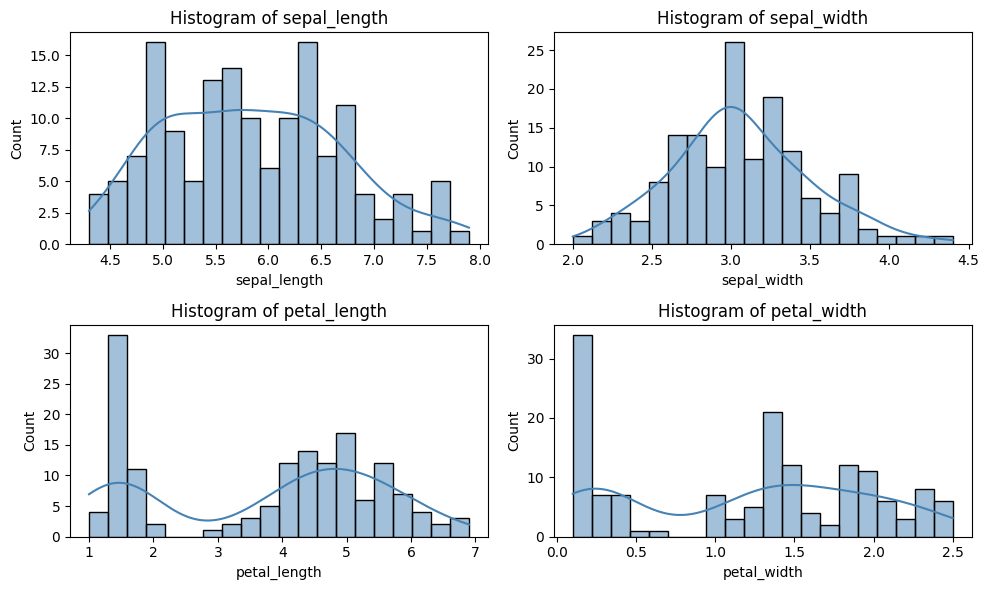

In [4]:
# 2. Histogram for each feature
plt.figure(figsize=(10, 6))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(iris[col], kde=True, bins=20, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

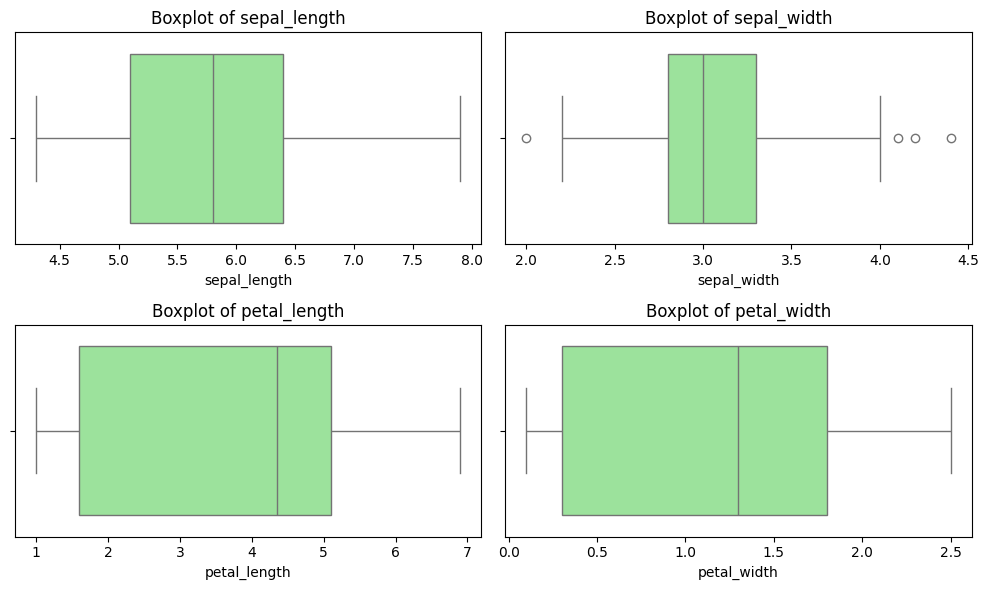

In [7]:
# 3. Boxplot for each feature
plt.figure(figsize=(10, 6))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=iris[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

In [8]:
# 4. Compare distributions and identify outliers using IQR
outlier_summary = {}
for col in numeric_features:
    q1 = iris[col].quantile(0.25)
    q3 = iris[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = iris[(iris[col] < lower) | (iris[col] > upper)][col]
    outlier_summary[col] = {
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_fence': lower,
        'upper_fence': upper,
        'outlier_count': outliers.count(),
    }
# Display as DataFrame
outlier_df = pd.DataFrame(outlier_summary).T
print('Outlier summary (IQR method):\n')
outlier_df

Outlier summary (IQR method):



,q1,q3,iqr,lower_fence,upper_fence,outlier_count
sepal_length,5.1,6.4,1.3,3.15,8.35,0.0
sepal_width,2.8,3.3,0.5,2.05,4.05,4.0
petal_length,1.6,5.1,3.5,-3.65,10.35,0.0
petal_width,0.3,1.8,1.5,-1.95,4.05,0.0
